In [6]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN,LSTM,GRU,Embedding,Dense
import matplotlib.pyplot as plt
import numpy as np
import time

# Load Dataset
vocab_size=10000
max_len=200

In [8]:
(x_train,y_train),(x_test,y_test)=imdb.load_data(num_words=vocab_size)

x_train=pad_sequences(x_train,maxlen=max_len)
x_test=pad_sequences(x_test,maxlen=max_len)

In [9]:
# Function to build models
def build_model(layer_type):

    model=Sequential()
    model.add(Embedding(vocab_size,128,input_length=max_len))

    if layer_type=="RNN":
        model.add(SimpleRNN(64))

    elif layer_type=="LSTM":
        model.add(LSTM(64))

    elif layer_type=="GRU":
        model.add(GRU(64))

    model.add(Dense(1,activation='sigmoid'))

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [11]:
# Train models
models=["RNN","LSTM","GRU"]
results = {}

for m in models:
    print(f"\nTraining {m} model...")

    model = build_model(m)

    start_time = time.time()

    history = model.fit(
        x_train, y_train,
        epochs=3,
        batch_size=64,
        validation_split=0.2,
        verbose=1
    )

    training_time = time.time() - start_time

    loss, accuracy = model.evaluate(x_test, y_test, verbose=0)

    results[m] = {
        "accuracy": accuracy,
        "time": training_time,
        "history": history
    }

# 🔹 Print Comparison
print("\n=== Model Comparison ===")
for m in results:
    print(f"{m} -> Accuracy: {results[m]['accuracy']:.4f}, Time: {results[m]['time']:.2f}s")



Training RNN model...
Epoch 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 69ms/step - accuracy: 0.7084 - loss: 0.5525 - val_accuracy: 0.8230 - val_loss: 0.4192
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.7695 - loss: 0.4844 - val_accuracy: 0.6674 - val_loss: 0.6046
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 66ms/step - accuracy: 0.8972 - loss: 0.2684 - val_accuracy: 0.7760 - val_loss: 0.5449

Training LSTM model...
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 54s 169ms/step - accuracy: 0.8009 - loss: 0.4295 - val_accuracy: 0.8664 - val_loss: 0.3261
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 172ms/step - accuracy: 0.9004 - loss: 0.2548 - val_accuracy: 0.8680 - val_loss: 0.3677
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 53s 169ms/step - accuracy: 0.9378 - loss: 0.1697 - val_accuracy: 0.8590 - val_loss: 0.3626

Training GRU model...
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 59s 181ms/step - accuracy: 0.7771 - loss: 0.4519 - val_accuracy: 0.8440 - val_loss: 0.3683
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 58s 186ms/step - 

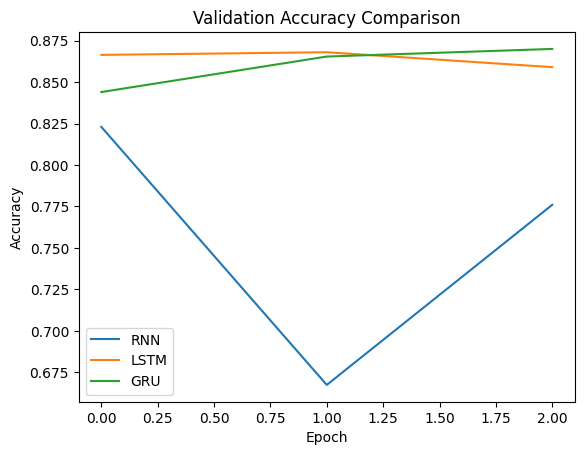

In [12]:
# 🔹 Plot Accuracy Graph
for m in results:
    plt.plot(results[m]['history'].history['val_accuracy'], label=m)

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()